Reading the CSV file

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\Talib\Desktop\DA - Projects\New Project Resume\Dataset\files v2\Cleaned Data\Fact_Sales.csv")
df

,Row_ID,Order_ID,Date_ID,Order_Date,Ship_Date,Delivery_Duration(Days),Ship_Mode,Customer_ID,Product_ID,Quantity,Unit_Price_BDT,Discount_Pct,Sales_BDT,Cost_BDT,Profit_BDT,Profit_Margin_Pct,Payment_Method,Is_Returned
0,1,ORD-105638,DATE-20230101,01-01-23,02-01-23,1,Standard,CUS-02321,PROD-00001,8,4771.66,0.042,36570.00,34620.64,1949.36,5.33,Cash on Delivery,False
1,2,ORD-102334,DATE-20230101,01-01-23,02-01-23,1,Standard,CUS-01456,PROD-00002,3,11470.75,0.100,30971.03,22946.73,8024.30,25.91,bKash,True
2,3,ORD-100570,DATE-20230101,01-01-23,08-01-23,7,Standard,CUS-00028,PROD-00003,11,58.85,0.077,597.50,548.44,49.06,8.21,Cash on Delivery,False
3,4,ORD-101183,DATE-20230101,01-01-23,02-01-23,1,Standard,CUS-00412,PROD-00004,4,11474.86,0.099,41355.40,38073.88,3281.52,7.93,bKash,False
4,5,ORD-104389,DATE-20230101,01-01-23,03-01-23,2,Standard,CUS-01955,PROD-00005,4,1722.10,0.196,5538.27,5080.03,458.24,8.27,Cash on Delivery,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9085,9086,ORD-103318,DATE-20251230,30-12-25,04-01-26,5,Standard,CUS-00533,PROD-07713,3,49009.23,0.052,139382.25,134636.13,4746.12,3.41,Cash on Delivery,False
9086,9087,ORD-108236,DATE-20251231,31-12-25,02-01-26,2,Same-Day,CUS-00895,PROD-01022,1,4270.98,0.213,3361.26,2882.84,478.42,14.23,bKash,False
9087,9088,ORD-106406,DATE-20251231,31-12-25,05-01-26,5,Standard,CUS-01913,PROD-02484,3,43433.88,0.051,123656.26,119053.06,4603.20,3.72,Cash on Delivery,False
9088,9089,ORD-103140,DATE-20251231,31-12-25,02-01-26,2,Standard,CUS-01687,PROD-07714,11,644.09,0.596,2862.34,-297.56,3159.90,110.40,Credit/Debit Card,False


YEARLY REVENUE

In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%y')

yearly_revenue = (
    df.groupby(df['Order_Date'].dt.year)
    .agg(
        Revenue=('Sales_BDT', 'sum'),
        Profit=('Profit_BDT', 'sum')
    )
    .reset_index()
)

yearly_revenue.rename(columns={'Order_Date': 'Year'}, inplace=True)


yearly_revenue = yearly_revenue.sort_values('Year')
yearly_revenue['YoY_Growth_Pct'] = yearly_revenue['Revenue'].pct_change() * 100

print("YEARLY REVENUE")
print(yearly_revenue.round(2))

YEARLY REVENUE
   Year      Revenue      Profit  YoY_Growth_Pct
0  2023  98215745.32  8915834.49             NaN
1  2024  80917292.80  7926550.62          -17.61
2  2025  97097772.71  8884046.66           20.00


MONTHLY REVENUE

In [8]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%y')

monthly_revenue = (
    df.groupby(df['Order_Date'].dt.to_period('M'))
      .agg(
          Revenue=('Sales_BDT', 'sum'),
          Profit=('Profit_BDT', 'sum')
      )
      .reset_index()
)
monthly_revenue = monthly_revenue.sort_values('Order_Date')
monthly_revenue['MoM_Growth_Pct'] = monthly_revenue['Revenue'].pct_change() * 100

monthly_revenue.rename(columns={'Order_Date': 'Year_Month'}, inplace=True)
monthly_revenue['Year_Month'] = monthly_revenue['Year_Month'].astype(str)

print("\nMONTHLY REVENUE")
print(monthly_revenue.round(2))


MONTHLY REVENUE
   Year_Month      Revenue      Profit  MoM_Growth_Pct
0     2023-01   8390315.47   686615.12             NaN
1     2023-02   7429154.33   537003.35          -11.46
2     2023-03   8510256.78   671412.59           14.55
3     2023-04   8480488.54   991542.49           -0.35
4     2023-05   7780524.26   558706.02           -8.25
5     2023-06   7394322.96   812132.14           -4.96
6     2023-07   6742566.49   594862.82           -8.81
7     2023-08   5506985.85   587567.27          -18.33
8     2023-09  11457361.44   803127.33          108.05
9     2023-10   7041602.37  1071142.49          -38.54
10    2023-11   9783331.56   835504.76           38.94
11    2023-12   9698835.27   766218.11           -0.86
12    2024-01   7809633.58   949397.82          -19.48
13    2024-02   5683661.08   471105.26          -27.22
14    2024-03   5317262.23   427349.56           -6.45
15    2024-04   6215128.19   709102.35           16.89
16    2024-05   5196310.83   462656.94          

SIGNIFICANT GROWTH / SLOWDOWN

In [9]:
print("\nTOP REVENUE DECLINE MONTHS")
print(
    monthly_revenue
    .dropna(subset=['MoM_Growth_Pct'])  # NaN ভ্যালু বাদ দেওয়ার জন্য
    .sort_values('MoM_Growth_Pct')
    .head(5)
    [['Year_Month', 'Revenue', 'MoM_Growth_Pct']]
    .round(2)
)


TOP REVENUE DECLINE MONTHS
   Year_Month     Revenue  MoM_Growth_Pct
30    2025-07  4370820.67          -74.68
20    2024-09  5017520.98          -43.89
9     2023-10  7041602.37          -38.54
25    2025-02  4455197.79          -37.50
32    2025-09  5436357.25          -31.34


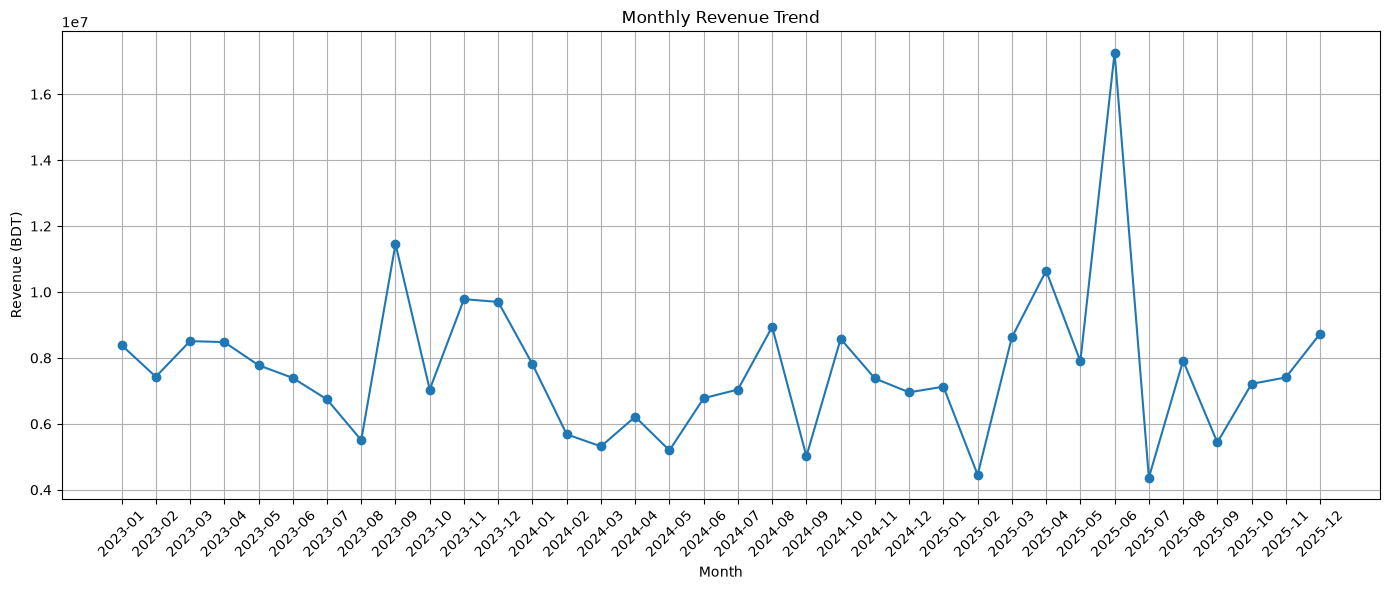

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue['Year_Month'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (BDT)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()